In [261]:
import numpy as np
import matplotlib.pyplot as plt

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100


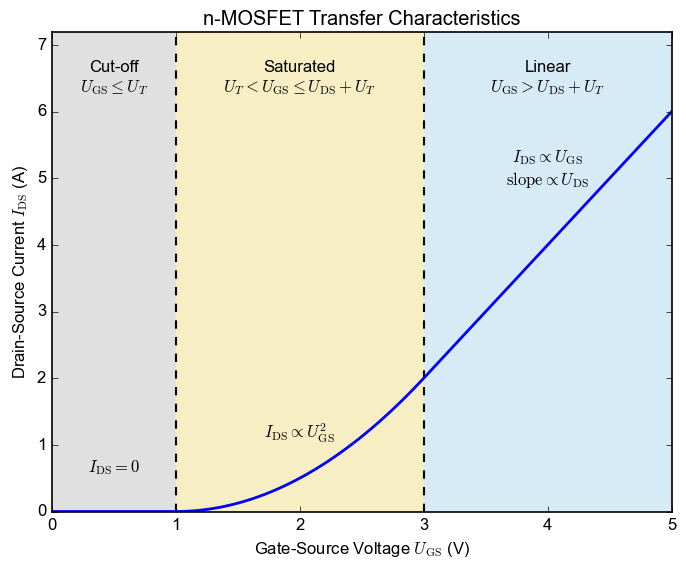

In [ ]:
U_T, alpha = 1.0, 1.0
U_GS = np.linspace(0, 5, 100)
U_DS = 2
V_OV = np.maximum(U_GS - U_T, 0)  # Overdrive voltage

# Full-region MOSFET current: triode for U_DS <= V_OV, saturation otherwise
I_D = np.where(
    U_DS <= V_OV,
    alpha * (V_OV - U_DS / 2) * U_DS,   # Triode region
    0.5 * alpha * V_OV**2               # Saturation region
)

# Region boundaries on U_GS axis for fixed U_DS
x_cutoff = U_T
x_linear = U_T + U_DS

fig, ax = plt.subplots()

# Fill operating regions
ax.axvspan(U_GS.min(), x_cutoff, color='#e0e0e0')
ax.axvspan(x_cutoff, x_linear, color='#f7efc3')
ax.axvspan(x_linear, U_GS.max(), color='#d7ebf7')

# Draw region boundaries
ax.axvline(x_cutoff, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x_linear, color='black', linestyle='--', linewidth=1.5)

# Plot I_D vs U_GS
ax.plot(U_GS, I_D, lw=2, color='blue')

# Region labels
y_label = 1.1 * np.max(I_D)
y_cond = 1.05 * np.max(I_D)
x1 = (U_GS.min() + x_cutoff) / 2
x2 = (x_cutoff + x_linear) / 2
x3 = (x_linear + U_GS.max()) / 2
offset = 0.1 * np.max(I_D)
y_model1 = np.interp(x1, U_GS, I_D) + offset
y_model2 = np.interp(x2, U_GS, I_D) + offset
y_model3 = np.interp(x3, U_GS, I_D) + 1.5*offset
ax.text(x1, y_label, 'Cut-off', ha='center')
ax.text(x2, y_label, 'Saturated', ha='center')
ax.text(x3, y_label, 'Linear', ha='center')
ax.text(x1, y_cond, r'$U_{\mathrm{GS}} \leq U_T$', ha='center')
ax.text(x2, y_cond, r'$U_T < U_{\mathrm{GS}} \leq U_{\mathrm{DS}} + U_T$', ha='center')
ax.text(x3, y_cond, r'$U_{\mathrm{GS}} > U_{\mathrm{DS}} + U_T$', ha='center')
ax.text(x1, y_model1, r'$I_{\mathrm{DS}} = 0$', ha='center')
ax.text(x2, y_model2, r'$I_{\mathrm{DS}} \propto U_{\mathrm{GS}}^2$', ha='center')
ax.text(x3, y_model3, '$I_{\\mathrm{DS}} \\propto U_{\\mathrm{GS}}$\n$\\mathrm{slope} \\propto U_{\\mathrm{DS}}$', ha='center')

# Plot settings
ax.set_xlabel(r'Gate-Source Voltage $U_\text{GS}$ (V)')
ax.set_ylabel(r'Drain-Source Current $I_\text{DS}$ (A)')
ax.set_title('n-MOSFET Transfer Characteristics')
ax.set_ylim(0, 1.2 * np.max(I_D))
# fig.savefig('Transfer.eps', bbox_inches='tight')
plt.show()

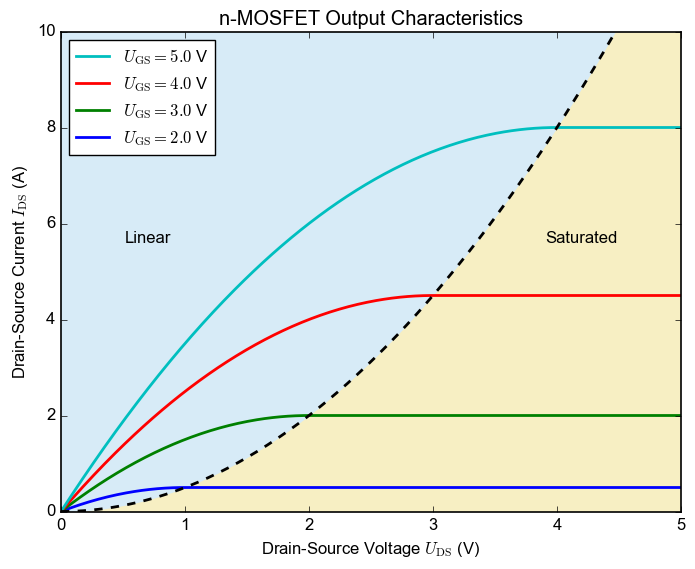

In [ ]:
U_DS = np.linspace(0, 5, 400)
U_GS_values = np.array([2, 3, 4, 5])
u = np.linspace(0, max(U_GS_values - U_T) + 2, 300)  # u = U_GS - U_T
boundary = 0.5 * alpha * u**2

fig, ax = plt.subplots()

# Fill the two operation regions
ax.fill_between(u, 0, boundary, color='#f7efc3')
ax.fill_between(u, boundary, 10, color='#d7ebf7')

# Plot I_D vs U_DS for each U_GS value
for U_GS_0 in U_GS_values:
    V_OV = max(U_GS_0 - U_T, 0)
    I_D = np.where(U_DS <= V_OV, alpha * (V_OV - 0.5 * U_DS) * U_DS, 0.5 * alpha * V_OV**2)
    ax.plot(U_DS, I_D, lw=2, label=rf'$U_\text{{GS}} = {U_GS_0:.1f}$ V')

# Plot the boundary between triode and saturation regions
ax.plot(u, boundary, 'k--', lw=2)
ax.text(0.7, 5.6, 'Linear', ha='center')
ax.text(4.2, 5.6, 'Saturated', ha='center')

# Plot settings
ax.set_xlabel(r'Drain-Source Voltage $U_{\text{DS}}$ (V)')
ax.set_ylabel(r'Drain-Source Current $I_{\text{DS}}$ (A)')
ax.set_title('n-MOSFET Output Characteristics')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=True, loc='upper left', numpoints=1, fontsize=12)
ax.set_xlim(0, 5)
ax.set_ylim(0, 10)
# fig.savefig('Output.eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


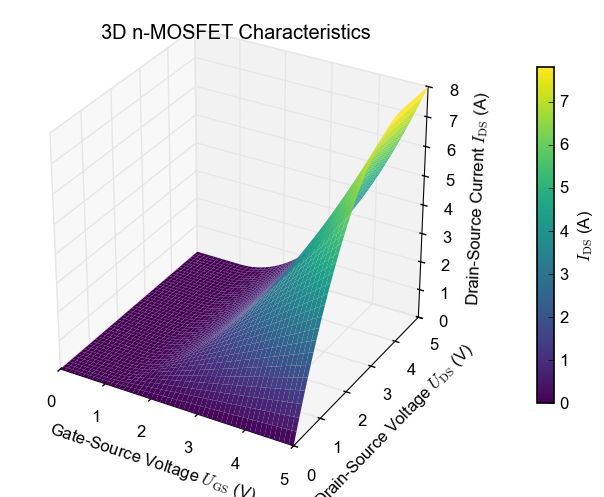

In [ ]:
# 3D plot: I_DS (z) vs U_GS (x) and U_DS (y)
U_GS_grid = np.linspace(0, 5, 501)
U_DS_grid = np.linspace(0, 5, 501)
U_GS_mesh, U_DS_mesh = np.meshgrid(U_GS_grid, U_DS_grid)

V_OV_mesh = np.maximum(U_GS_mesh - U_T, 0)
I_DS_mesh = np.where(
    U_DS_mesh <= V_OV_mesh,
    alpha * (V_OV_mesh - 0.5 * U_DS_mesh) * U_DS_mesh,
    0.5 * alpha * V_OV_mesh**2
)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(U_GS_mesh, U_DS_mesh, I_DS_mesh, cmap='viridis', edgecolor='none')

# Use the same scale on all three axes; fix axis max to 5
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_zlim(0, 8)
ax.set_box_aspect((1, 1, 1))

ax.set_xlabel(r'Gate-Source Voltage $U_{\text{GS}}$ (V)')
ax.set_ylabel(r'Drain-Source Voltage $U_{\text{DS}}$ (V)')
ax.set_zlabel(r'Drain-Source Current $I_{\text{DS}}$ (A)')
ax.set_title('3D n-MOSFET Characteristics')
fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.12, label=r'$I_{\text{DS}}$ (A)')
# fig.savefig('3D.eps', bbox_inches='tight')
plt.show()

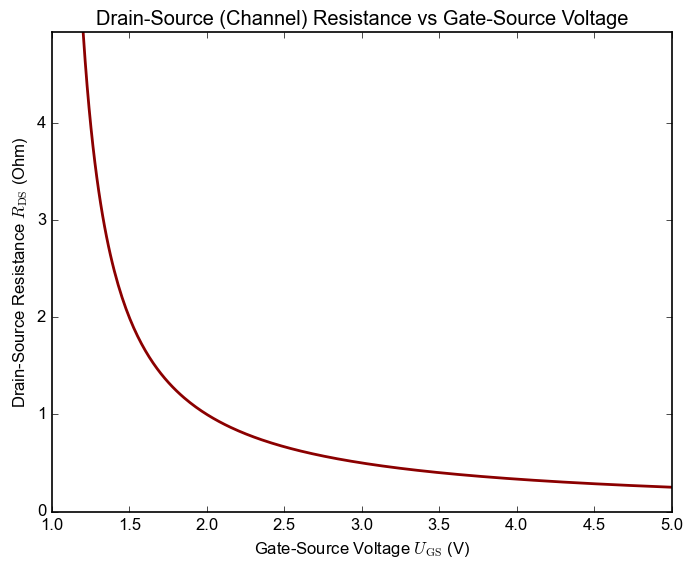

In [ ]:
U_GS = np.linspace(0, 5, 400)
R_DS = np.where(U_GS > U_T, 1 / (alpha * (U_GS - U_T)), np.nan)

plt.plot(U_GS, R_DS, lw=2, color='darkred')
plt.xlabel(r'Gate-Source Voltage $U_{\text{GS}}$ (V)')
plt.ylabel(r'Drain-Source Resistance $R_{\text{DS}}$ (Ohm)')
plt.title(r'Drain-Source (Channel) Resistance vs Gate-Source Voltage')
plt.ylim(0, np.nanpercentile(R_DS, 95))
# plt.savefig('RDS.eps', bbox_inches='tight')
plt.show()